# Import required libraries

In [7]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix


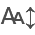

In [8]:
import itables   #rendering iteractive tables in jupyter notebook
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# Load the dataset

In [9]:
df = pd.read_csv("TMIS Selvabakkiam - Employee-Attrition.csv")

### print the first five rows

In [10]:
df.head()

Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                         1            80                 0   
1  ...                         4            80                 1   
2  ...                         2            80                 0   
3  ...                         3            80                 0   
4  ...                         4            80                 1   

   TotalWorkingYears  TrainingTimesLastYear WorkLifeBalance  YearsAtCompany  \
0                  8                      0               1               6   
1                 10                      3               3              10   
2                  7                      3               3               0   
3                  8                      3               3               8   
4                  6                      3               3               2   

  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager  
0                  4                        0                     5  
1                  7                        1                     7  
2                  0                        0                     0  
3                  7                        3                     0  
4                  2                        2                     2  

[5 rows x 35 columns]

In [11]:
df.shape

(1470, 35)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# EDA

In [13]:
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]
if features_with_na:
    for feature in features_with_na:
        print(feature, np.round(df[feature].isnull().sum(), 4), "missing values")
else:
    print("No missing values in the dataset.")

No missing values in the dataset.


In [14]:
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=columns_to_drop)

In [15]:
df.describe().T

count          mean          std     min     25%  \
Age                       1470.0     36.923810     9.135373    18.0    30.0   
DailyRate                 1470.0    802.485714   403.509100   102.0   465.0   
DistanceFromHome          1470.0      9.192517     8.106864     1.0     2.0   
Education                 1470.0      2.912925     1.024165     1.0     2.0   
EnvironmentSatisfaction   1470.0      2.721769     1.093082     1.0     2.0   
HourlyRate                1470.0     65.891156    20.329428    30.0    48.0   
JobInvolvement            1470.0      2.729932     0.711561     1.0     2.0   
JobLevel                  1470.0      2.063946     1.106940     1.0     1.0   
JobSatisfaction           1470.0      2.728571     1.102846     1.0     2.0   
MonthlyIncome             1470.0   6502.931293  4707.956783  1009.0  2911.0   
MonthlyRate               1470.0  14313.103401  7117.786044  2094.0  8047.0   
NumCompaniesWorked        1470.0      2.693197     2.498009     0.0     1.0   
PercentSalaryHike         1470.0     15.209524     3.659938    11.0    12.0   
PerformanceRating         1470.0      3.153741     0.360824     3.0     3.0   
RelationshipSatisfaction  1470.0      2.712245     1.081209     1.0     2.0   
StockOptionLevel          1470.0      0.793878     0.852077     0.0     0.0   
TotalWorkingYears         1470.0     11.279592     7.780782     0.0     6.0   
TrainingTimesLastYear     1470.0      2.799320     1.289271     0.0     2.0   
WorkLifeBalance           1470.0      2.761224     0.706476     1.0     2.0   
YearsAtCompany            1470.0      7.008163     6.126525     0.0     3.0   
YearsInCurrentRole        1470.0      4.229252     3.623137     0.0     2.0   
YearsSinceLastPromotion   1470.0      2.187755     3.222430     0.0     0.0   
YearsWithCurrManager      1470.0      4.123129     3.568136     0.0     2.0   

                              50%       75%      max  
Age                          36.0     43.00     60.0  
DailyRate                   802.0   1157.00   1499.0  
DistanceFromHome              7.0     14.00     29.0  
Education                     3.0      4.00      5.0  
EnvironmentSatisfaction       3.0      4.00      4.0  
HourlyRate                   66.0     83.75    100.0  
JobInvolvement                3.0      3.00      4.0  
JobLevel                      2.0      3.00      5.0  
JobSatisfaction               3.0      4.00      4.0  
MonthlyIncome              4919.0   8379.00  19999.0  
MonthlyRate               14235.5  20461.50  26999.0  
NumCompaniesWorked            2.0      4.00      9.0  
PercentSalaryHike            14.0     18.00     25.0  
PerformanceRating             3.0      3.00      4.0  
RelationshipSatisfaction      3.0      4.00      4.0  
StockOptionLevel              1.0      1.00      3.0  
TotalWorkingYears            10.0     15.00     40.0  
TrainingTimesLastYear         3.0      3.00      6.0  
WorkLifeBalance               3.0      3.00      4.0  
YearsAtCompany                5.0      9.00     40.0  
YearsInCurrentRole            3.0      7.00     18.0  
YearsSinceLastPromotion       1.0      3.00     15.0  
YearsWithCurrManager          3.0      7.00     17.0

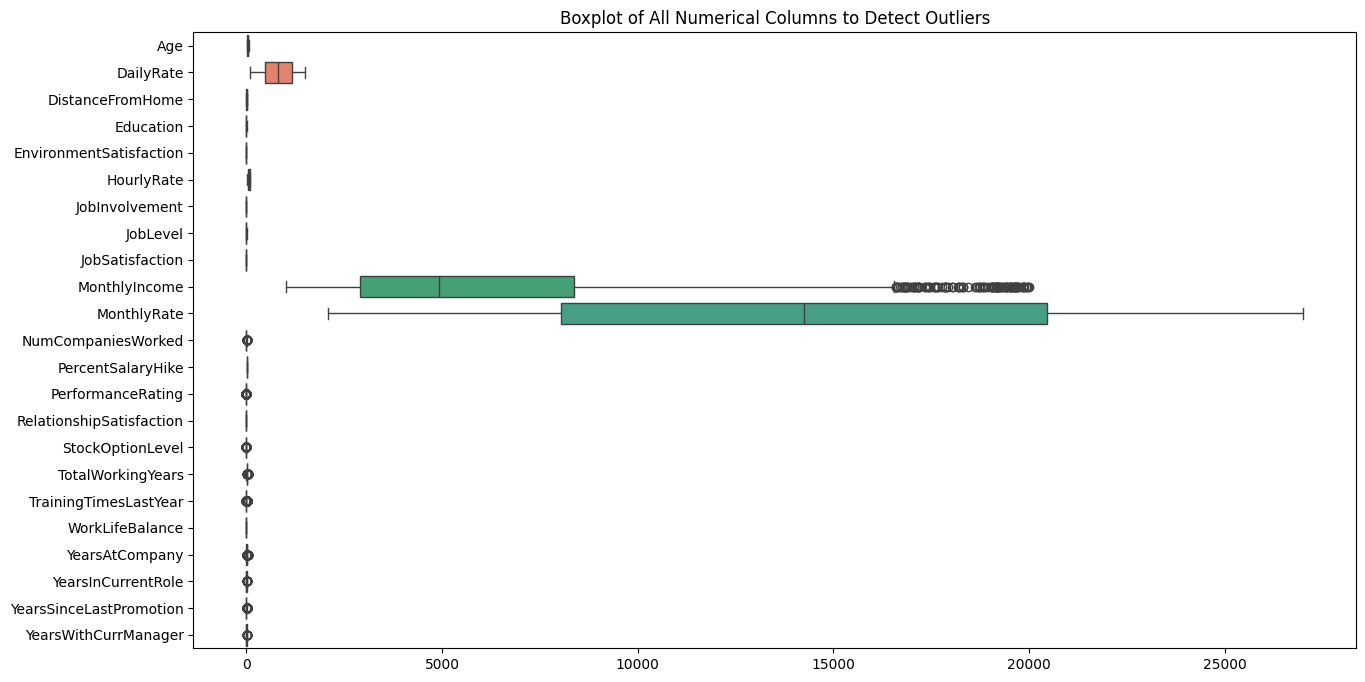

In [16]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of All Numerical Columns to Detect Outliers")
plt.show()

In [17]:


def replace_outliers_with_median(df):
    total_outliers_before = 0
    total_outliers_after = 0
    
    # Loop through numerical columns
    for column in df.select_dtypes(include=np.number).columns:
        while True:  # Keep replacing until no more outliers
            Q1 = df[column].quantile(0.25) 
            Q3 = df[column].quantile(0.75)  
            IQR = Q3 - Q1  
            
            # Define lower and upper bound
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Count outliers before replacement
            outlier_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
            total_outliers_before += outlier_count

            if outlier_count == 0:
                break  
            
            # Compute the median of the column
            median_value = df[column].median()
            
            # Replace outliers with the median
            df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), 
                                  median_value, df[column])

    # Count outliers after replacement
    for column in df.select_dtypes(include=np.number).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        total_outliers_after += df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

    print("Total outliers before replacement:", total_outliers_before)
    print("Total outliers after replacement:", total_outliers_after)
    print("Outliers successfully replaced!")

replace_outliers_with_median(df)


Total outliers before replacement: 1852
Total outliers after replacement: 0
Outliers successfully replaced!


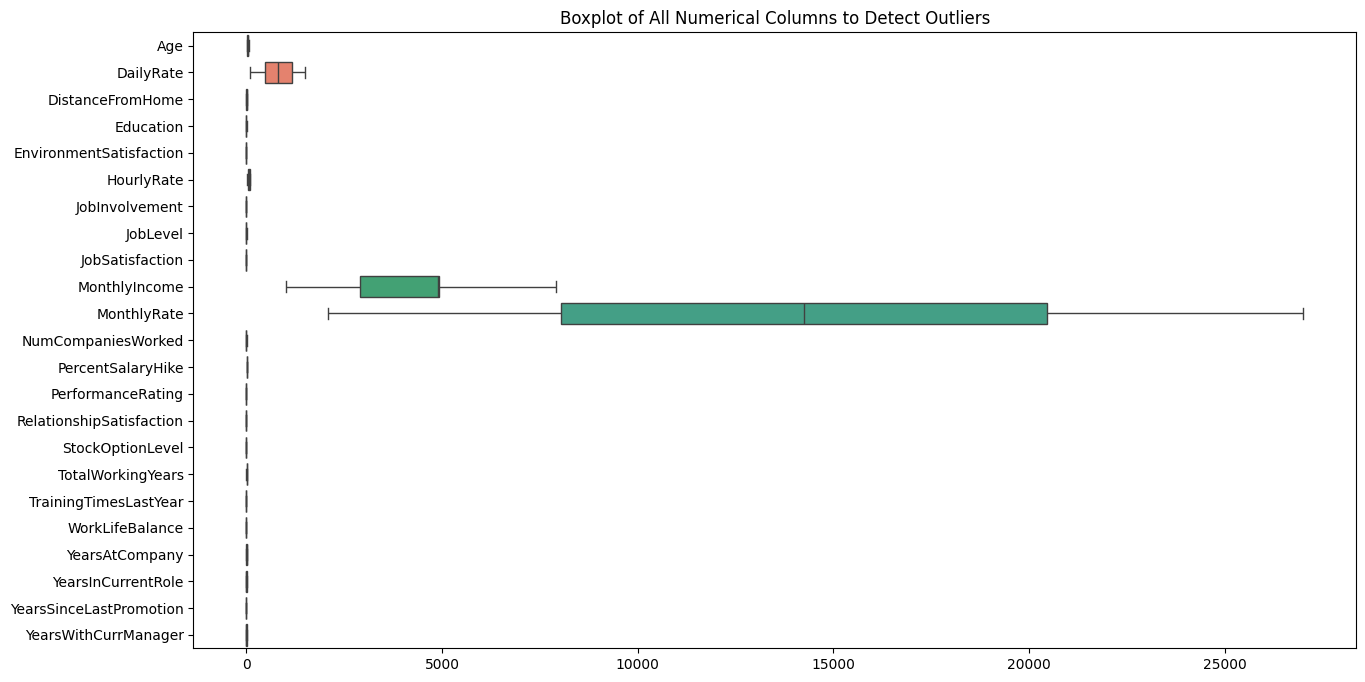

In [18]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of All Numerical Columns to Detect Outliers")
plt.show()

In [19]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [20]:
for col in categorical_cols:
    print(col,df[col].unique())
    print("_" * 50)

Attrition ['Yes' 'No']
__________________________________________________
BusinessTravel ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
__________________________________________________
Department ['Sales' 'Research & Development' 'Human Resources']
__________________________________________________
EducationField ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
__________________________________________________
Gender ['Female' 'Male']
__________________________________________________
JobRole ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
__________________________________________________
MaritalStatus ['Single' 'Married' 'Divorced']
__________________________________________________
OverTime ['Yes' 'No']
__________________________________________________


In [21]:
label_cols=categorical_cols
encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

In [22]:
df.head()

Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1          1               1                        3       1  ...   
2          2               4                        4       1  ...   
3          4               1                        4       0  ...   
4          1               3                        1       1  ...   

   PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0                3.0                         1               0.0   
1                3.0                         4               1.0   
2                3.0                         2               0.0   
3                3.0                         3               0.0   
4                3.0                         4               1.0   

   TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  \
0                8.0                    3.0                1             6.0   
1               10.0                    3.0                3            10.0   
2                7.0                    3.0                3             0.0   
3                8.0                    3.0                3             8.0   
4                6.0                    3.0                3             2.0   

   YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager  
0                 4.0                      0.0                   5.0  
1                 7.0                      1.0                   7.0  
2                 0.0                      0.0                   0.0  
3                 7.0                      1.0                   0.0  
4                 2.0                      2.0                   2.0  

[5 rows x 31 columns]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   int32  
 2   BusinessTravel            1470 non-null   int32  
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   int32  
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   int32  
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   int32  
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   int32  
 14  JobSatis

In [24]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])


In [25]:
df.head()

Age  Attrition  BusinessTravel  DailyRate  Department  \
0  0.446350          1               2   0.742527           2   
1  1.322365          0               1  -1.297775           1   
2  0.008343          1               2   1.414363           1   
3 -0.429664          0               1   1.461466           1   
4 -1.086676          0               2  -0.524295           1   

   DistanceFromHome  Education  EducationField  EnvironmentSatisfaction  \
0         -1.010909  -0.891688               1                -0.660531   
1         -0.147150  -1.868426               1                 0.254625   
2         -0.887515  -0.891688               4                 1.169781   
3         -0.764121   1.061787               1                 1.169781   
4         -0.887515  -1.868426               3                -1.575686   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0       0  ...                0.0                 -1.584178         -1.030466   
1       1  ...                0.0                  1.191438          0.488877   
2       1  ...                0.0                 -0.658973         -1.030466   
3       0  ...                0.0                  0.266233         -1.030466   
4       1  ...                0.0                  1.191438          0.488877   

   TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  \
0          -0.091986               0.544124        -2.493820        0.167501   
1           0.469093               0.544124         0.338096        1.322135   
2          -0.372526               0.544124         0.338096       -1.564451   
3          -0.091986               0.544124         0.338096        0.744818   
4          -0.653065               0.544124         0.338096       -0.987134   

   YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager  
0           -0.013060                -1.098774              0.297624  
1            0.886888                 0.442445              0.891659  
2           -1.212991                -1.098774             -1.187464  
3            0.886888                 0.442445             -1.187464  
4           -0.613026                 1.983664             -0.593429  

[5 rows x 31 columns]

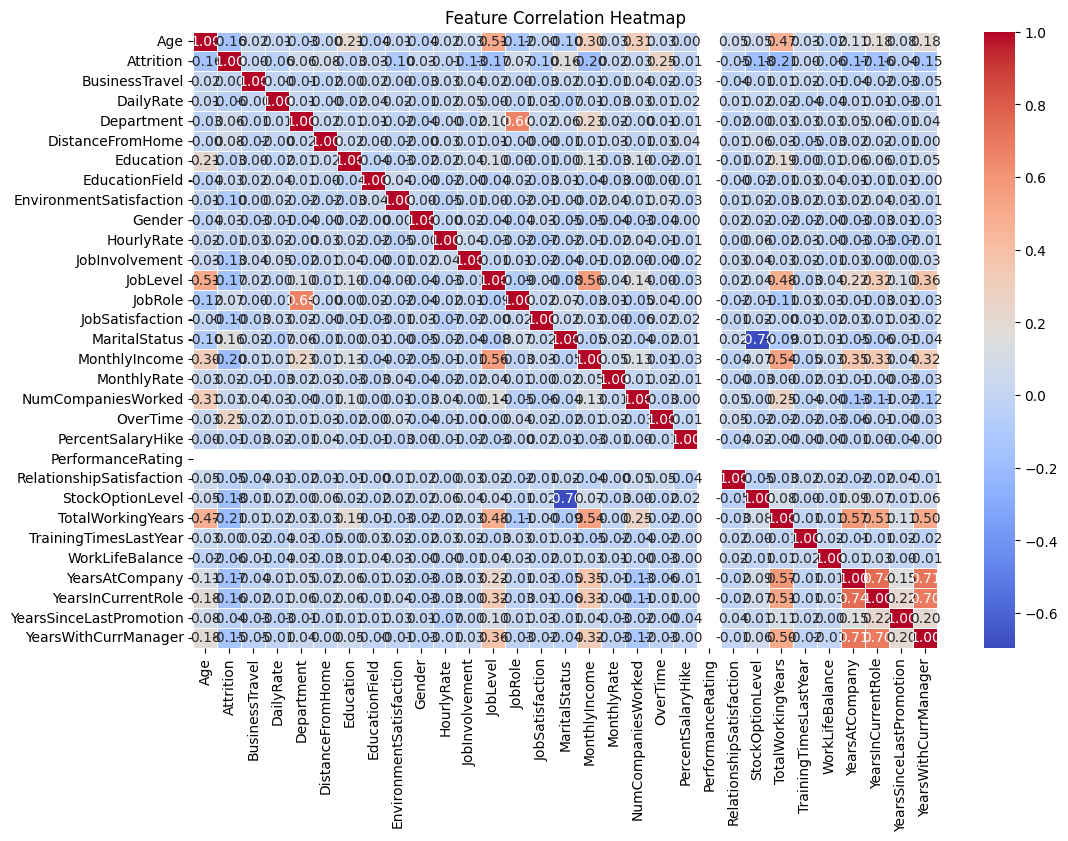

In [26]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
X=df.drop(columns=["Attrition"])
y=df["Attrition"]

In [28]:
X

Age  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0     0.446350               2   0.742527           2         -1.010909   
1     1.322365               1  -1.297775           1         -0.147150   
2     0.008343               2   1.414363           1         -0.887515   
3    -0.429664               1   1.461466           1         -0.764121   
4    -1.086676               2  -0.524295           1         -0.887515   
...        ...             ...        ...         ...               ...   
1465 -0.101159               1   0.202082           1          1.703764   
1466  0.227347               2  -0.469754           1         -0.393938   
1467 -1.086676               2  -1.605183           1         -0.640727   
1468  1.322365               1   0.546677           2         -0.887515   
1469 -0.320163               2  -0.432568           1         -0.147150   

      Education  EducationField  EnvironmentSatisfaction  Gender  HourlyRate  \
0     -0.891688               1                -0.660531       0    1.383138   
1     -1.868426               1                 0.254625       1   -0.240677   
2     -0.891688               4                 1.169781       1    1.284725   
3      1.061787               1                 1.169781       0   -0.486709   
4     -1.868426               3                -1.575686       1   -1.274014   
...         ...             ...                      ...     ...         ...   
1465  -0.891688               3                 0.254625       1   -1.224807   
1466  -1.868426               3                 1.169781       1   -1.175601   
1467   0.085049               1                -0.660531       1    1.038693   
1468   0.085049               3                 1.169781       1   -0.142264   
1469   0.085049               3                -0.660531       1    0.792660   

      ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0     ...                0.0                 -1.584178         -1.030466   
1     ...                0.0                  1.191438          0.488877   
2     ...                0.0                 -0.658973         -1.030466   
3     ...                0.0                  0.266233         -1.030466   
4     ...                0.0                  1.191438          0.488877   
...   ...                ...                       ...               ...   
1465  ...                0.0                  0.266233          0.488877   
1466  ...                0.0                 -1.584178          0.488877   
1467  ...                0.0                 -0.658973          0.488877   
1468  ...                0.0                  1.191438         -1.030466   
1469  ...                0.0                 -1.584178         -1.030466   

      TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  \
0             -0.091986               0.544124        -2.493820   
1              0.469093               0.544124         0.338096   
2             -0.372526               0.544124         0.338096   
3             -0.091986               0.544124         0.338096   
4             -0.653065               0.544124         0.338096   
...                 ...                    ...              ...   
1465           0.469093               0.544124         0.338096   
1466           0.188553               0.544124         0.338096   
1467          -0.653065               0.544124         0.338096   
1468           0.469093               0.544124        -1.077862   
1469          -0.653065               0.544124         1.754054   

      YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  \
0           0.167501           -0.013060                -1.098774   
1           1.322135            0.886888                 0.442445   
2          -1.564451           -1.212991                -1.098774   
3           0.744818            0.886888                 0.442445   
4          -0.987134           -0.613026                 1.983664   
...              

In [29]:
y

Attrition
Loading ITables v2.2.4 from the init_notebook_mode cell... (need help?)


In [30]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
smote = SMOTE(random_state=42)

In [33]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [34]:
print(y_train_smote.shape)

(1956,)


In [35]:
print(y_train_smote.value_counts())

Attrition
0    978
1    978
Name: count, dtype: int64


In [36]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
ab = AdaBoostClassifier(n_estimators=100, random_state=42)


In [37]:
rf.fit(X_train_smote, y_train_smote)
gb.fit(X_train_smote, y_train_smote)
ab.fit(X_train_smote, y_train_smote)


AdaBoostClassifier(n_estimators=100, random_state=42)

In [38]:
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_ab = ab.predict(X_test)

In [39]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ab))

Random Forest Accuracy: 0.8707482993197279
Gradient Boosting Accuracy: 0.8537414965986394
AdaBoost Accuracy: 0.8673469387755102


In [40]:
from sklearn.ensemble import VotingClassifier


voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('ab', ab)], voting='hard'
)
voting_clf.fit(X_train_smote, y_train_smote)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('ab',
                              AdaBoostClassifier(n_estimators=100,
                                                 random_state=42))])

In [41]:
y_pred_voting = voting_clf.predict(X_test)


In [42]:
from sklearn.metrics import classification_report


print("\nVoting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))
print("\nClassification Report:\n", classification_report(y_test, y_pred_voting))


Voting Classifier Accuracy: 0.8673469387755102

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93       255
           1       0.50      0.31      0.38        39

    accuracy                           0.87       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.85      0.87      0.85       294

